In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from vrAnalysis.database import get_database
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript.configs.placefield_structure import (
    PlacefieldStructureConfig,
    PlacefieldDataGenerator,
    StationaryDiagonalResidualConfig,
    StationaryLowRankResidualConfig,
    HeteroscedasticDiagonalResidualConfig,
    PoissonLikeResidualConfig,
    FullCovariancePerPositionResidualConfig,
    LowRankNuisanceConfig,
    StationaryGaussianNuisanceConfig,
)

plt.rcParams["font.size"] = 14

sessiondb = get_database("vrSessions")
registry = PopulationRegistry()

## Load a session

In [2]:
isession = 0
spks_type = "oasis"

session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))
session = session_iterable[isession]
print(session)
print("Environments:", session.environments)
print("Trial environments:", session.trial_environment)
for env in session.environments:
    print(env, "num_trials:", np.sum(session.trial_environment == env))
    

B2Session(mouse_name='ATL012', date='2023-01-20', session_id='702', spks_type='oasis')
Environments: [1]
Trial environments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
1 num_trials: 28


## Fit noise model via PlacefieldStructureConfig

`cfg.fit()` handles everything internally:
- loads population data from the registry
- selects reliable, active ROIs (reliability + fraction-active)
- builds the `(N, K, T)` per-trial placefield tensor `Y`
- fits the chosen residual model
- returns a `PlacefieldStructureFit` with `Y`, `P`, `idx_keep_rois`, and a ready-to-use `generator`

In [3]:
cfg = PlacefieldStructureConfig(
    residual_type="poisson_like",
    smooth_width=5.0,
    num_bins=100,
    reliability_cutoff=0.1,
    fraction_active_cutoff=0.1,
    min_trials_per_env=5,
    trial_subsample_seed=0,
)

fit = cfg.fit(session, registry)

print(f"Kept ROIs         : {fit.idx_keep_rois.sum()} / {fit.idx_keep_rois.shape[0]}")
print(f"Environments used : {fit.environments}  (n_envs={fit.n_envs})")
print(f"Trials per env    : {fit.n_trials_used}")
print(f"Y shape (N,E*K,T) : {fit.Y.shape}   [N={fit.n_neurons}, K_per_env={cfg.num_bins}, E={fit.n_envs}, T={fit.n_trials}]")
print(f"P shape (N, E*K)  : {fit.P.shape}")
print(f"True spectrum[:5] : {fit.true_spectrum[:5].round(4)}")

Kept ROIs         : 660 / 4236
Environments used : [1]  (n_envs=1)
Trials per env    : 27
Y shape (N,E*K,T) : (660, 100, 27)   [N=660, K_per_env=100, E=1, T=27]
P shape (N, E*K)  : (660, 100)
True spectrum[:5] : [1.2062660e+09 5.6758323e+08 4.6719014e+08 3.1386186e+08 1.4510234e+08]


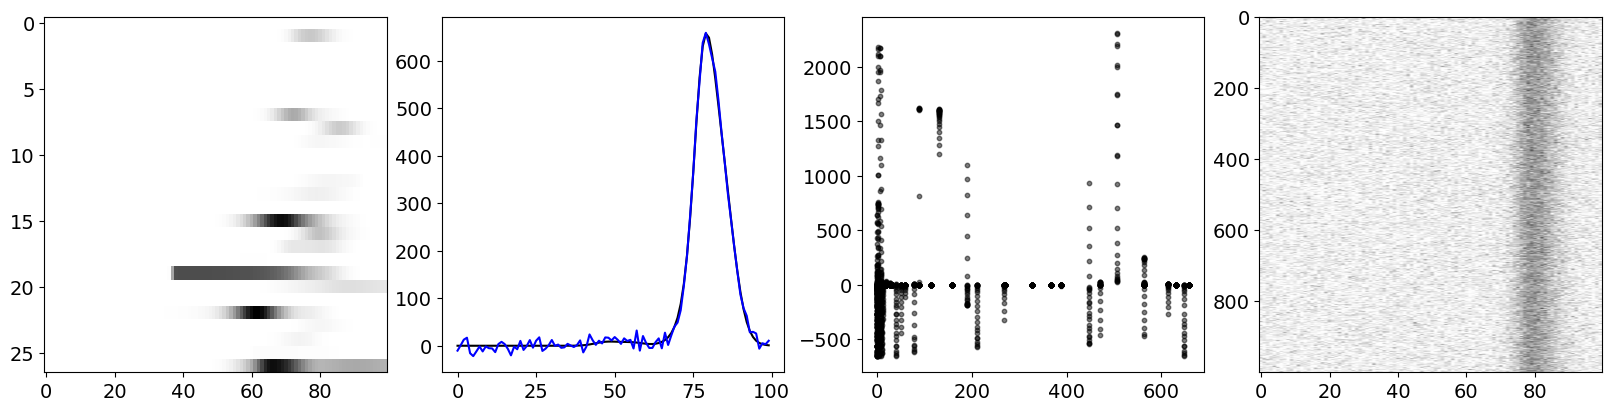

In [6]:
ineuron = 10
P = fit.P[ineuron]
Y = fit.Y[ineuron].T
sim = fit.generator.sample(n_trials=1000, return_unfolded=False)[ineuron].T


plt.close('all')
fig, ax = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
ax[0].imshow(Y, cmap="gray_r", vmin=0, interpolation="none", aspect="auto")
ax[1].plot(P, color="k")
ax[1].plot(sim.mean(axis=0), color="blue")
ax[2].scatter(np.repeat(P[None], Y.shape[0]), Y - P[None], color=("k", 0.5), s=10)
ax[3].imshow(sim, cmap="gray_r", vmin=0, aspect="auto")
plt.show()

In [7]:
fit.Y.shape, fit.P.shape

((660, 100, 27), (660, 100))

In [5]:
np.allclose(fit.Y.mean(axis=-1), fit.P, atol=1e-2, rtol=1e-2)

False

## Inspect the fitted residual config

In [13]:
rc = fit.residual_config
print("Type:", type(rc).__name__)
print("a  (Fano slope, first 8 neurons):", rc.a[:8].round(4))
print("b  (baseline var, first 8 neurons):", rc.b[:8].round(4))
print("min_variance:", rc.min_variance)

# The fitted mean placefield P_ is stored on the config for inspection
print("P_ shape (same as fit.P):", rc.P_.shape)

Type: PoissonLikeResidualConfig
a  (Fano slope, first 8 neurons): [  357.4501   746.2152   641.1814  -948.7184   -92.2355    56.5753
 -1571.3401    14.7523]
b  (baseline var, first 8 neurons): [219309.72    7071.572  28289.809 128270.14  122878.35   46269.082
  14870.32   93142.8  ]
min_variance: 1e-08
P_ shape (same as fit.P): (660, 100)


## Sample synthetic data from the generator

In [14]:
gen = fit.generator

Y_sim = gen.sample(n_trials=fit.n_trials)                   # (N, K, T)
X_sim = gen.sample(n_trials=fit.n_trials, return_unfolded=True)  # (N, K*T)

print("Simulated Y (N, K, T):", Y_sim.shape)
print("Simulated X unfolded (N, S):", X_sim.shape)
print("True spectrum (SVD of P):", gen.true_spectrum[:5].round(4))

Simulated Y (N, K, T): (660, 100, 27)
Simulated X unfolded (N, S): (660, 2700)
True spectrum (SVD of P): [1.2062660e+09 5.6758323e+08 4.6719014e+08 3.1386186e+08 1.4510234e+08]


## True spectrum vs observed PCA spectrum

The true spectrum comes from the SVD of `P` (no noise). The observed PCA spectrum of `Y` is inflated by noise. The simulated PCA spectrum should match the observed one if the noise model is right.

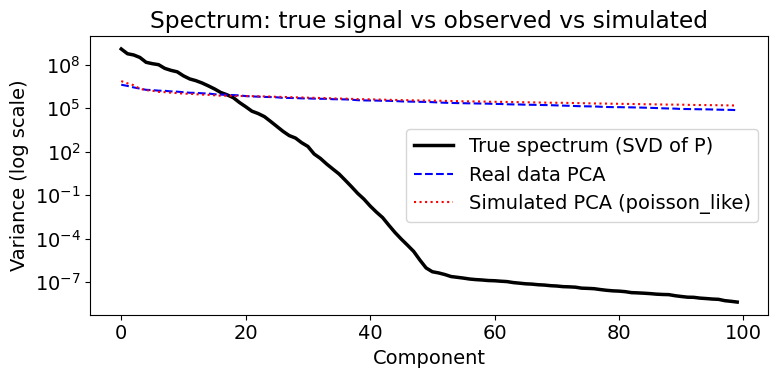

In [15]:
N, K, T = fit.Y.shape
true_spectrum = fit.true_spectrum
rank_plot = min(N, K)

def _pca_spectrum(Y_nkt):
    """Empirical PCA spectrum of a (N, K, T) tensor (unfolded, centred)."""
    N_, K_, T_ = Y_nkt.shape
    X = Y_nkt.reshape(N_, K_ * T_)
    X_c = X - X.mean(axis=1, keepdims=True)
    _, s, _ = np.linalg.svd(X_c, full_matrices=False)
    return (s ** 2) / max(K_ * T_ - 1, 1)

pca_real = _pca_spectrum(fit.Y)
pca_sim  = _pca_spectrum(Y_sim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(true_spectrum[:rank_plot], "k-", lw=2.5, label="True spectrum (SVD of P)")
ax.semilogy(pca_real[:rank_plot], "b--", lw=1.5, label="Real data PCA")
ax.semilogy(pca_sim[:rank_plot], "r:", lw=1.5, label="Simulated PCA (poisson_like)")
ax.set_xlabel("Component")
ax.set_ylabel("Variance (log scale)")
ax.set_title("Spectrum: true signal vs observed vs simulated")
ax.legend()
plt.tight_layout()
plt.show()

## Standalone residual config API

`from_data(Y)` works directly on the `(N, K, T)` tensor — no session or registry needed. Useful for iterating in a notebook.

In [9]:
Y = fit.Y  # pull out the data tensor once

rc_diag    = StationaryDiagonalResidualConfig.from_data(Y)
rc_hetero  = HeteroscedasticDiagonalResidualConfig.from_data(Y)
rc_poisson = PoissonLikeResidualConfig.from_data(Y)
rc_lowrank = StationaryLowRankResidualConfig.from_data(Y, n_components=5)

print("StationaryDiagonal  sigma mean:", rc_diag.sigma.mean().round(4))
print("Heteroscedastic     sigma2 mean:", rc_hetero.sigma2.mean().round(4))
print("PoissonLike         a mean:", rc_poisson.a.mean().round(4), " b mean:", rc_poisson.b.mean().round(4))
print("StationaryLowRank   W shape:", rc_lowrank.W.shape, " psi mean:", rc_lowrank.psi.mean().round(4))

StationaryDiagonal  sigma mean: 150.2437
Heteroscedastic     sigma2 mean: 58518.566
PoissonLike         a mean: 881.2142  b mean: -30829.678
StationaryLowRank   W shape: (815, 5)  psi mean: 49294.7991


## Parametric construction (from_distribution)

Use explicit parameters instead of fitting from data — useful for controlled sweeps.

In [ ]:
rc_param = PoissonLikeResidualConfig.from_distribution(a=1.0, b=0.05)
gen_param = PlacefieldDataGenerator(fit.P, rc_param)

Y_param = gen_param.sample(n_trials=50)
print("Parametric simulated Y shape:", Y_param.shape)
print("True spectrum (shared P):", gen_param.true_spectrum[:5].round(4))

## Nuisance signals

`NuisanceConfig` adds position-independent structure in the unfolded `(N, S)` space — brain-state fluctuations, global gain, etc.

In [ ]:
nuisance_lr   = LowRankNuisanceConfig(rank=3, variance=0.1)
nuisance_gauss = StationaryGaussianNuisanceConfig(sigma=0.05)

gen_with_nuisance = PlacefieldDataGenerator(fit.P, rc_poisson, nuisance_lr)
Y_noisy = gen_with_nuisance.sample(n_trials=fit.n_trials)
print("With low-rank nuisance, Y shape:", Y_noisy.shape)

pca_noisy = _pca_spectrum(Y_noisy)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(true_spectrum[:rank_plot], "k-", lw=2.5, label="True spectrum")
ax.semilogy(pca_sim[:rank_plot], "r:", lw=1.5, label="Poisson-like (no nuisance)")
ax.semilogy(pca_noisy[:rank_plot], "g--", lw=1.5, label="Poisson-like + rank-3 nuisance")
ax.set_xlabel("Component")
ax.set_ylabel("Variance (log scale)")
ax.set_title("Effect of nuisance on observed spectrum")
ax.legend()
plt.tight_layout()
plt.show()

## Spectrum comparison across residual models (bootstrap)

This is the intended experimental loop: does a CV estimator recover the true spectrum under each noise regime?

In [ ]:
n_bootstrap = 8

residual_cfgs = {
    "stationary_diagonal":    rc_diag,
    "heteroscedastic_diagonal": rc_hetero,
    "poisson_like":            rc_poisson,
    "stationary_low_rank":     rc_lowrank,
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(true_spectrum[:rank_plot], "k-", lw=2.5, label="True spectrum (P)", zorder=5)
ax.semilogy(pca_real[:rank_plot], "k--", lw=1.5, alpha=0.5, label="Real data PCA")

colors = plt.colormaps["tab10"](np.linspace(0, 0.6, len(residual_cfgs)))
for color, (name, rc) in zip(colors, residual_cfgs.items()):
    spectra = []
    for _ in range(n_bootstrap):
        g = PlacefieldDataGenerator(fit.P, rc)
        spec = _pca_spectrum(g.sample(fit.n_trials))
        spectra.append(spec)
    spectra = np.stack(spectra)  # (n_bootstrap, min(N, S))
    mu = spectra.mean(axis=0)
    sd = spectra.std(axis=0)
    ax.semilogy(mu[:rank_plot], color=color, label=name)
    ax.fill_between(
        np.arange(rank_plot),
        np.maximum((mu - sd)[:rank_plot], 1e-12),
        (mu + sd)[:rank_plot],
        alpha=0.2, color=color,
    )

ax.set_xlabel("Component")
ax.set_ylabel("Variance (log scale)")
ax.set_title("Simulated PCA spectrum under different noise models")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Pipeline usage: process()

`process()` is what the pipeline calls — returns a serialisable summary dict (true spectrum, empirical PCA spectrum, dimensions).

In [ ]:
result = cfg.process(session, registry)

for k, v in result.items():
    if isinstance(v, np.ndarray):
        print(f"{k:20s}: shape={v.shape}")
    else:
        print(f"{k:20s}: {v}")

## Placefield visualisation

Visualise the mean placefield `P` sorted by preferred position, alongside one simulated trial.

In [ ]:
# P has shape (N, E*K) — sort neurons by their peak across all env×position bins
peak_pos = np.argmax(fit.P, axis=1)
sort_idx = np.argsort(peak_pos)

P_sorted    = fit.P[sort_idx]        # (N, E*K)
Y_sim_sorted = Y_sim[sort_idx]       # (N, E*K, T)

# Normalise each neuron for display
P_norm  = P_sorted  / np.maximum(P_sorted.max(axis=1, keepdims=True), 1e-9)
Y0_norm = Y_sim_sorted[:, :, 0] / np.maximum(Y_sim_sorted[:, :, 0].max(axis=1, keepdims=True), 1e-9)

K_per_env = cfg.num_bins
env_boundaries = [K_per_env * i for i in range(1, fit.n_envs)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(
    axes,
    [P_norm, Y0_norm],
    [f"Mean placefield P (E*K={fit.n_bins})", "Simulated trial 0"],
):
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="hot", vmin=0, vmax=1)
    for xb in env_boundaries:
        ax.axvline(xb - 0.5, color="cyan", lw=1, ls="--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(f"Position bin  (envs: {fit.environments}, K={K_per_env} each)")
    ax.set_ylabel("Neuron (sorted by peak)")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()